# SPX Bass SV Calibration

Calibrates the Bass stochastic-volatility model to the S&P 500 option surface (2024-02-20)
using two reference models:

- **Brownian Motion** — arithmetic BM, dollar vol from calibrated SABR alpha
- **Arithmetic SABR** (β=0) — calibrated jointly to the full surface

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from IPython.display import clear_output, display

from bass_sv import BassSV
from reference_models import BrownianMotion, ArithmeticSABR
from utils import Density, mc_iv
from svi import SVI

### Data loading

In [2]:
DATA_FILE = '../../data/spx-2024-02-20.xlsx'
S0 = 4975.85

fwd = pd.read_excel(DATA_FILE, sheet_name='Forwards', index_col=0)
opt = pd.read_excel(DATA_FILE, sheet_name='Options',  index_col=[0, 1, 2])

print(f'S0 = {S0}')
print(f'Available maturities: {len(fwd)}')
print(fwd[['timeToMaturity', 'forwardPrice']].head(8).to_string())

S0 = 4975.85
Available maturities: 49
            timeToMaturity  forwardPrice
maturity                                
2024-02-20          0.0006     4976.3000
2024-02-21          0.0033     4976.4497
2024-02-22          0.0060     4977.8490
2024-02-23          0.0088     4979.5002
2024-02-26          0.0170     4979.2507
2024-02-27          0.0197     4980.4995
2024-02-28          0.0225     4979.5006
2024-02-29          0.0252     4981.2982


In [3]:
# Same target maturities as the reference example
target_maturities = [0.1237, 0.2388, 0.3539, 0.584, 0.7376, 0.9102, 1.0826, 1.332]

T_all = fwd['timeToMaturity'].values
mats  = fwd.index.tolist()
selected_mats = [mats[np.argmin(np.abs(T_all - t))] for t in target_maturities]

print('Selected maturities:')
for m in selected_mats:
    print(f'  {m}  T={fwd.loc[m, "timeToMaturity"]:.4f}  F={fwd.loc[m, "forwardPrice"]:.2f}')

Selected maturities:
  2024-04-05  T=0.1237  F=5001.74
  2024-05-17  T=0.2388  F=5028.86
  2024-06-28  T=0.3539  F=5052.75
  2024-09-20  T=0.5840  F=5099.18
  2024-11-15  T=0.7376  F=5131.31
  2025-01-17  T=0.9102  F=5166.64
  2025-03-21  T=1.0826  F=5192.37
  2025-06-20  T=1.3320  F=5236.16


In [4]:
# Unpack into arrays — same naming as the reference example
# T: time to maturity, F: forward price
# X: log-moneyness, W: total variance, K: absolute strike, IV: implied vol
min_abs_delta = 0.01

T, F, X, K, W, IV = [], [], [], [], [], []

for m in selected_mats:
    T.append(fwd.loc[m, 'timeToMaturity'])
    F.append(fwd.loc[m, 'forwardPrice'])

    sub  = opt.loc[m]
    otm  = sub[sub['OTM'] == True].copy()
    mask = otm['delta'].abs() >= min_abs_delta
    otm  = otm[mask]

    x_  = otm['logStrike'].values
    w_  = otm['totalVar'].values
    k_  = otm.index.get_level_values('strike').values.astype(float)
    iv_ = otm['impliedVol'].values

    order = np.argsort(x_)
    X.append(x_[order]);  W.append(w_[order])
    K.append(k_[order]);  IV.append(iv_[order])

print('Loaded maturities:', [f'{t:.4f}' for t in T])

Loaded maturities: ['0.1237', '0.2388', '0.3539', '0.5840', '0.7376', '0.9102', '1.0826', '1.3320']


### SVI Calibration — Raw Market Marginals

In [5]:
svi_models       = {}
market_marginals = {}

for i in range(len(T)):
    maturity_time = T[i]
    forward_price = F[i]

    svi_model = SVI.calibrate(X[i], W[i], no_arbitrage=False)
    svi_models[maturity_time] = svi_model

    s_min  = forward_price * 0.2
    s_max  = forward_price * 5.0
    s_grid = np.linspace(s_min, s_max, 10_000)

    cdf_values = svi_model.cdf(S0, s_grid)
    cdf_values = np.clip(np.maximum.accumulate(np.maximum(cdf_values, 0)), 0, 1)

    cdf_func = interp1d(s_grid, cdf_values, bounds_error=False,
                        fill_value=(0, 1), kind='linear')
    uniq_c, uniq_i = np.unique(cdf_values, return_index=True)
    qf_func  = interp1d(uniq_c, s_grid[uniq_i], bounds_error=False,
                        fill_value='extrapolate', kind='linear')

    market_marginals[maturity_time] = Density(cdf=cdf_func, qf=qf_func)

    prob_grid   = np.linspace(0.001, 0.999, 1000)
    expectation = np.trapz(qf_func(prob_grid), prob_grid)
    print(f'T={maturity_time:.4f}  F={forward_price:.2f}  E[S]={expectation:.2f}')

print(f'\nCalibrated {len(market_marginals)} SVI models')

T=0.1237  F=5001.74  E[S]=4967.37
T=0.2388  F=5028.86  E[S]=4967.59
T=0.3539  F=5052.75  E[S]=4967.50
T=0.5840  F=5099.18  E[S]=4968.15
T=0.7376  F=5131.31  E[S]=4968.30
T=0.9102  F=5166.64  E[S]=4968.36
T=1.0826  F=5192.37  E[S]=4967.92
T=1.3320  F=5236.16  E[S]=4967.87

Calibrated 8 SVI models


In [6]:
# SVI fit quality table
T_arr = np.array(T)
rows  = []
for i, maturity_time in enumerate(T):
    iv_fit = svi_models[maturity_time].implied_vol(F[i], maturity_time, K[i])
    rows.append({
        'maturity': maturity_time,
        'n_points': len(IV[i]),
        'RMSE':     np.sqrt(np.mean((iv_fit - IV[i])**2)),
        'max_err':  np.max(np.abs(iv_fit - IV[i])),
    })

pd.DataFrame(rows).set_index('maturity')

,n_points,RMSE,max_err
maturity,,,
0.1237,97,0.001047,0.003233
0.2388,270,0.000909,0.003442
0.3539,308,0.002455,0.020272
0.5840,106,0.001037,0.003948
0.7376,112,0.002504,0.018273
0.9102,120,0.002747,0.019890
1.0826,65,0.002227,0.006090
1.3320,66,0.002308,0.006902


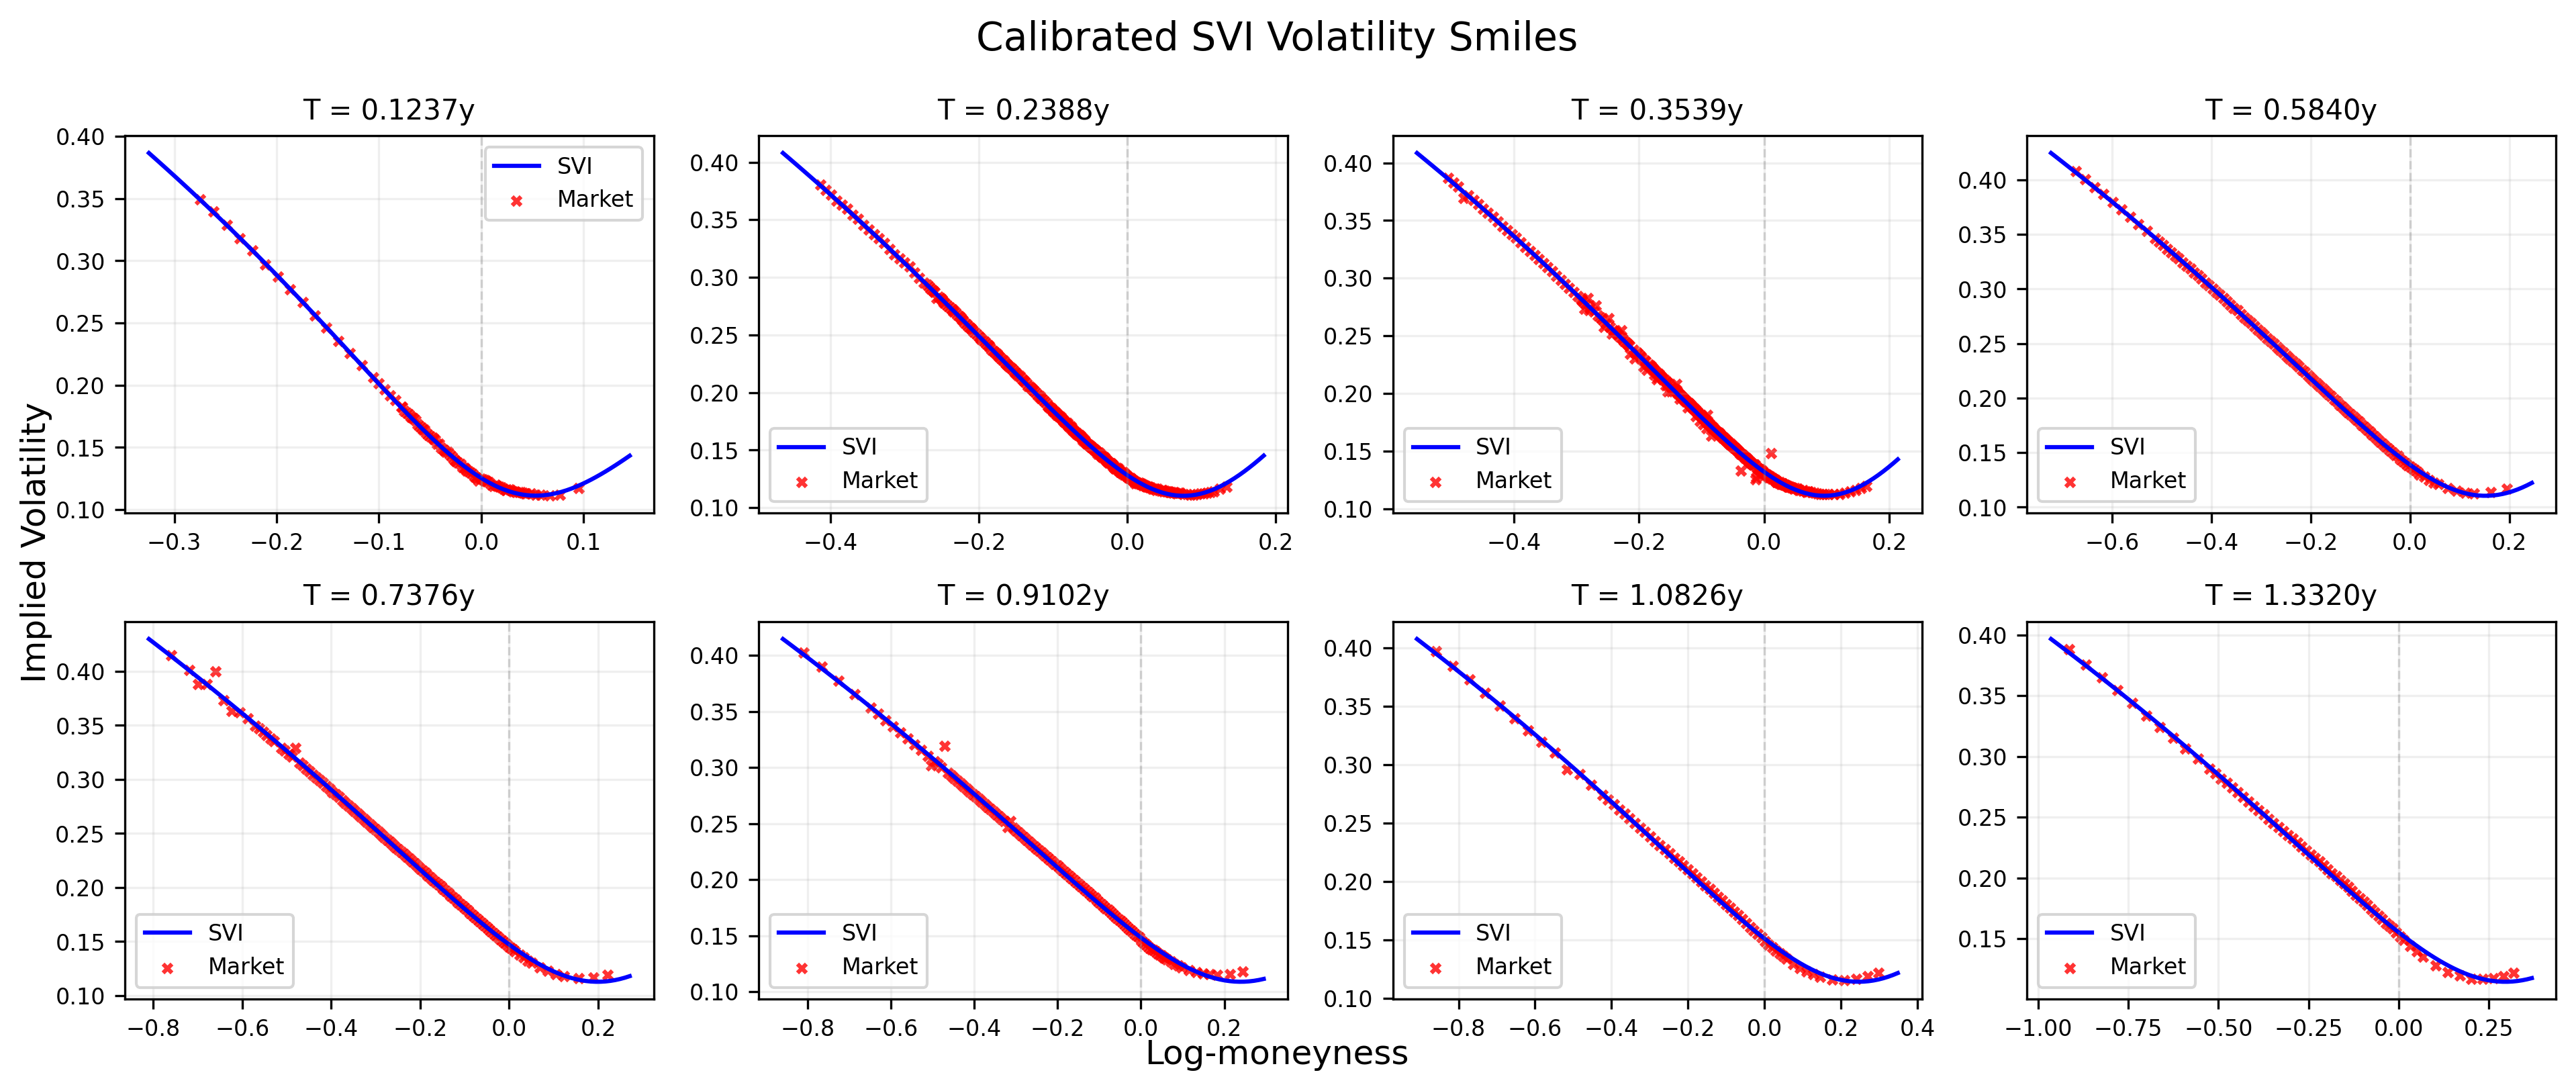

In [7]:
# SVI smile plot — all 8 maturities (target maturities selected)
n_cols = 4
n_rows = int(np.ceil(len(T) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.7 * n_rows), dpi=300)
axes = axes.flatten()

for i, maturity_time in enumerate(T):
    ax     = axes[i]
    svi    = svi_models[maturity_time]
    x_fine = np.linspace(X[i].min() - 0.05, X[i].max() + 0.05, 100)
    iv_svi = np.sqrt(svi.total_var(x_fine) / maturity_time)

    ax.plot(x_fine, iv_svi, color='blue', lw=1.5, label='SVI')
    ax.scatter(X[i], IV[i], color='red', s=10, marker='x', alpha=0.8, label='Market')
    ax.axvline(0, color='gray', ls='--', alpha=0.3, lw=0.8)
    ax.set_title(f'T = {maturity_time:.4f}y', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

for j in range(len(T), len(axes)):
    axes[j].remove()

fig.text(0.5,  0.02, 'Log-moneyness',     ha='center',  fontsize=12)
fig.text(0.02, 0.5,  'Implied Volatility', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Calibrated SVI Volatility Smiles', fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08, left=0.06)
plt.savefig('SVI_to_market.pdf', bbox_inches='tight')
plt.show()

### Arithmetic SABR Calibration

In [8]:
# Flatten all maturities into one array for joint calibration
t_flat, k_flat, iv_flat = [], [], []

for maturity_time, forward_price, k_market, iv_market in zip(T, F, K, IV):
    k_absolute = k_market * forward_price if np.mean(k_market) < 10 else k_market
    t_flat.extend([maturity_time] * len(k_absolute))
    k_flat.extend(k_absolute)
    iv_flat.extend(iv_market)

t_sabr  = np.array(t_flat)
k_sabr  = np.array(k_flat)
iv_sabr = np.array(iv_flat)

bounds = [(0.01, 3000.0), (-0.99, 0.99), (0.01, 30.0)]
sabr_model = ArithmeticSABR.calibrate(S0, t_sabr, k_sabr, iv_sabr, bounds)

print('Arithmetic SABR calibrated:')
print(f'  α (alpha) = {sabr_model.alpha:.4f}')
print(f'  ρ (rho)   = {sabr_model.rho:.4f}')
print(f'  ν (nu)    = {sabr_model.nu:.4f}')

iv_fit    = sabr_model.implied_vol(t_sabr, k_sabr)
rmse_sabr = np.sqrt(np.mean((iv_fit - iv_sabr)**2))
max_err   = np.max(np.abs(iv_fit - iv_sabr))
print(f'  RMSE = {rmse_sabr:.5f}  max_err = {max_err:.5f}')

Arithmetic SABR calibrated:
  α (alpha) = 704.7331
  ρ (rho)   = -0.6660
  ν (nu)    = 0.9664
  RMSE = 0.02063  max_err = 0.10779


In [9]:
# SABR fit quality table + smile plot
plot_data = []
fit_stats = []
for i, maturity_time in enumerate(T):
    forward_price = F[i]
    k_abs   = K[i] * forward_price if np.mean(K[i]) < 10 else K[i]
    k_fine  = np.linspace(0.95 * k_abs.min(), 1.05 * k_abs.max(), 150)
    iv_fine = sabr_model.implied_vol([maturity_time] * len(k_fine), k_fine)
    iv_mkt  = sabr_model.implied_vol([maturity_time] * len(k_abs), k_abs)
    rmse    = np.sqrt(np.mean((iv_mkt - IV[i])**2))
    max_e   = np.max(np.abs(iv_mkt - IV[i]))
    plot_data.append({'T': maturity_time, 'F': forward_price, 'strikes': k_abs,
                      'IV': IV[i], 'k_fine': k_fine, 'iv_sabr_fine': iv_fine})
    fit_stats.append({'maturity': maturity_time, 'n_points': len(IV[i]),
                      'RMSE': rmse, 'max_err': max_e})

pd.DataFrame(fit_stats).set_index('maturity')

,n_points,RMSE,max_err
maturity,,,
0.1237,97,0.027298,0.096455
0.2388,270,0.023072,0.073337
0.3539,308,0.013767,0.045198
0.5840,106,0.002246,0.005101
0.7376,112,0.010054,0.026766
0.9102,120,0.018950,0.053428
1.0826,65,0.028368,0.077717
1.3320,66,0.039955,0.107788


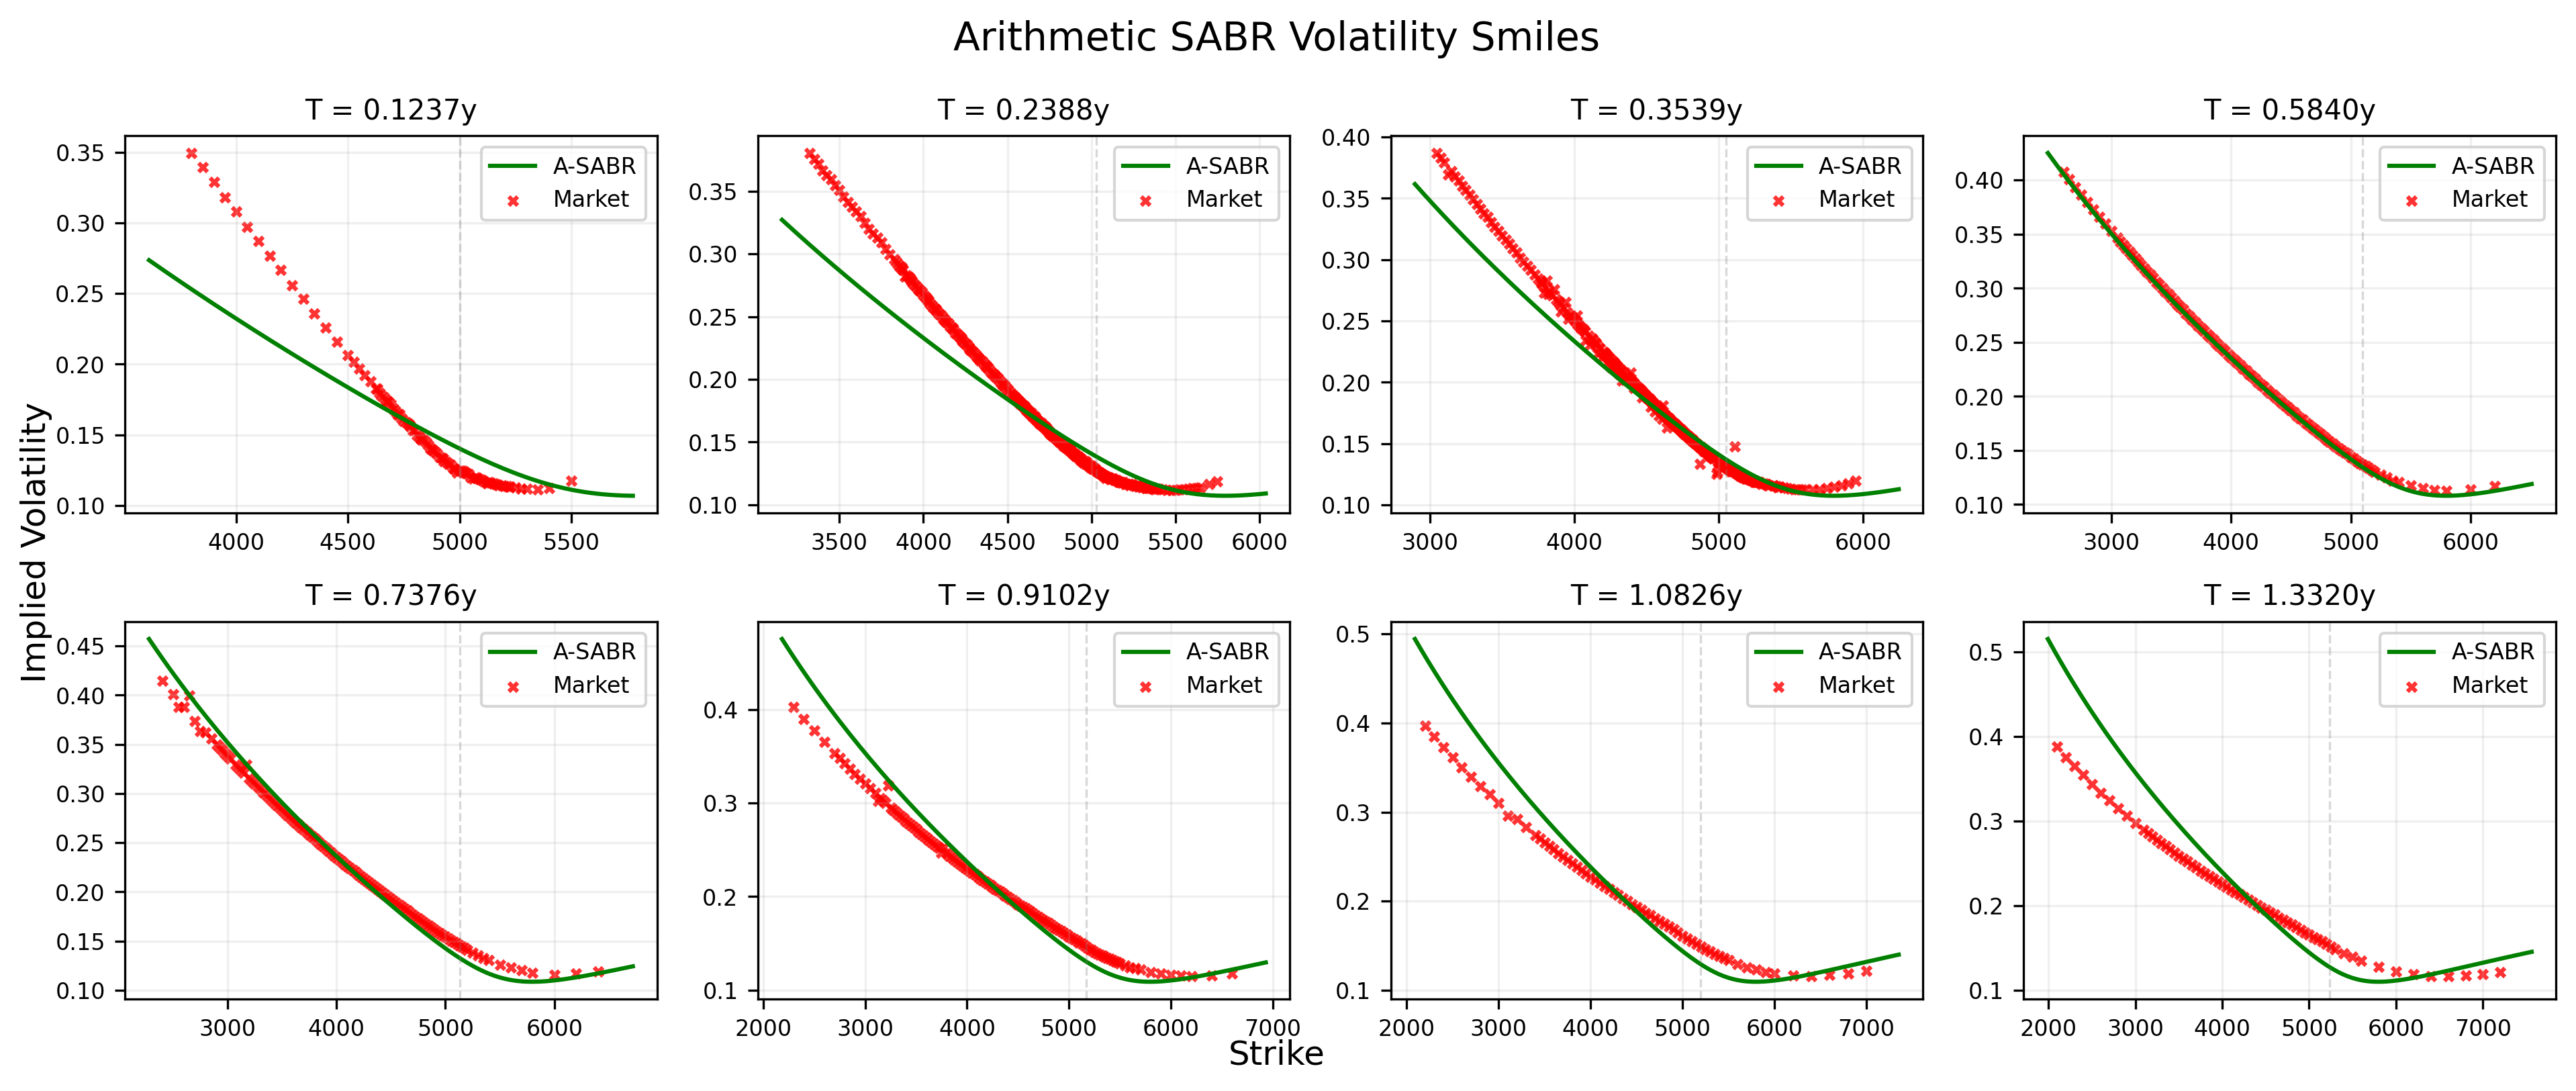

In [10]:
n_cols = 4
n_rows = int(np.ceil(len(T) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.7 * n_rows), dpi=300)
axes = axes.flatten()

for i, d in enumerate(plot_data):
    ax = axes[i]
    ax.plot(d['k_fine'], d['iv_sabr_fine'], color='green', lw=1.5, label='A-SABR')
    ax.scatter(d['strikes'], d['IV'], color='red', s=10, marker='x', alpha=0.8, label='Market')
    ax.axvline(d['F'], color='gray', ls='--', alpha=0.3, lw=0.8)
    ax.set_title(f'T = {d["T"]:.4f}y', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

for j in range(len(T), len(axes)):
    axes[j].remove()

fig.text(0.5,  0.02, 'Strike',            ha='center',  fontsize=12)
fig.text(0.02, 0.5,  'Implied Volatility', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Arithmetic SABR Volatility Smiles', fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08, left=0.06)
plt.savefig('ASABR_to_market.pdf', bbox_inches='tight')
plt.show()

### Bass LV Calibration

In [11]:
all_maturities     = sorted(market_marginals.keys())
filtered_marginals = {t: market_marginals[t] for t in all_maturities}

# Interval lengths: first = T[0], rest = diffs
tt = np.array(all_maturities)
tt = np.concatenate([tt[:1], np.diff(tt)])
print('Interval lengths:', np.round(tt, 4))

Interval lengths: [0.1237 0.1151 0.1151 0.2301 0.1536 0.1726 0.1724 0.2494]


In [12]:
# Brownian Motion reference — dollar vol = SABR alpha
bm_model = BrownianMotion(s0=S0, sigma=sabr_model.alpha)
print(f'BM sigma = {bm_model.sigma:.4f}')

bass_bm = BassSV(S0, bm_model, filtered_marginals)
result_bm = bass_bm.calibrate(N=20_000, nsigma=7, tol=1e-3, max_iter=100, verbose=True)

BM sigma = 704.7331
  T=0.1237: interval 0 — trivial Brenier map (no iteration)
  T=0.2388: 10 iters, ‖ΔF‖∞ = 8.77e-04
  T=0.3539: 10 iters, ‖ΔF‖∞ = 7.65e-04
  T=0.5840: 6 iters, ‖ΔF‖∞ = 9.67e-04
  T=0.7376: 20 iters, ‖ΔF‖∞ = 5.70e-05
  T=0.9102: 31 iters, ‖ΔF‖∞ = 3.29e-04
  T=1.0826: 28 iters, ‖ΔF‖∞ = 5.92e-04
  T=1.3320: 26 iters, ‖ΔF‖∞ = 5.01e-04


In [13]:
# Arithmetic SABR reference — globally calibrated sabr_model
bass_sabr = BassSV(S0, sabr_model, filtered_marginals)
result_sabr = bass_sabr.calibrate(N=20_000, nsigma=7, tol=1e-3, max_iter=100, verbose=True)

/Users/aleksandrpolakov/Desktop/Курсовая МатФак/bass_sv_git/industrial/calibration/../reference_models/arithmetic_sabr.py:76: RuntimeWarning: invalid value encountered in divide
  np.where(np.abs(chi) > eps, log * z / ((s0 - k) * chi), 1/s0),


  T=0.1237: interval 0 — trivial Brenier map (no iteration)
  T=0.2388: 12 iters, ‖ΔF‖∞ = 8.79e-04
  T=0.3539: 13 iters, ‖ΔF‖∞ = 7.26e-04
  T=0.5840: 10 iters, ‖ΔF‖∞ = 9.27e-04
  T=0.7376: 23 iters, ‖ΔF‖∞ = 2.86e-05
  T=0.9102: 25 iters, ‖ΔF‖∞ = 3.41e-04
  T=1.0826: 23 iters, ‖ΔF‖∞ = 5.98e-04
  T=1.3320: 23 iters, ‖ΔF‖∞ = 5.16e-04


### Smile Check — SVI vs Bass BM

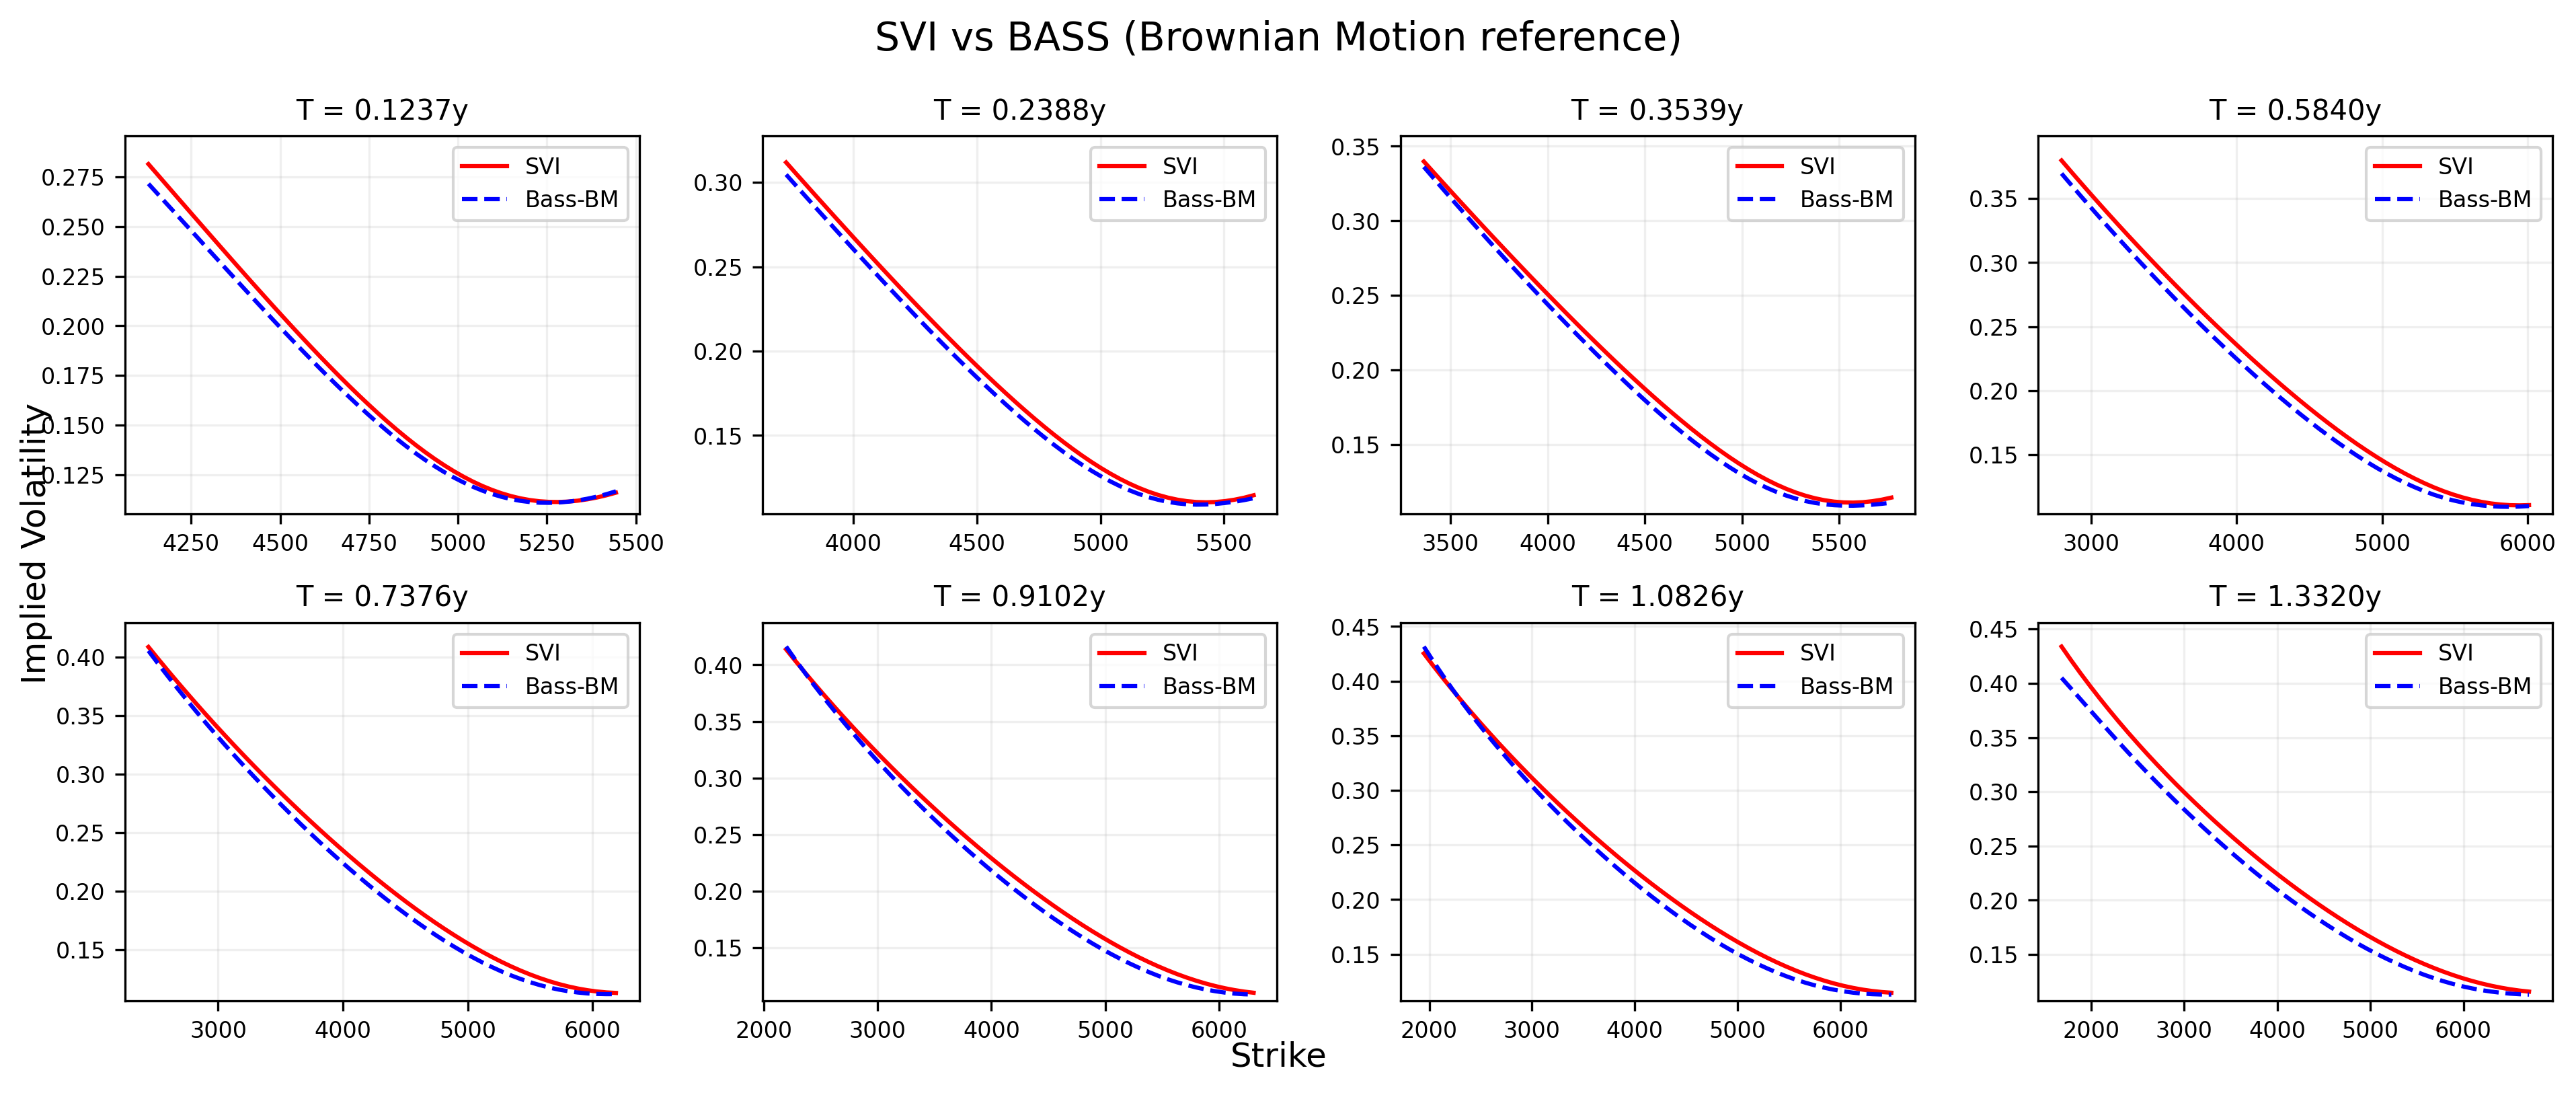

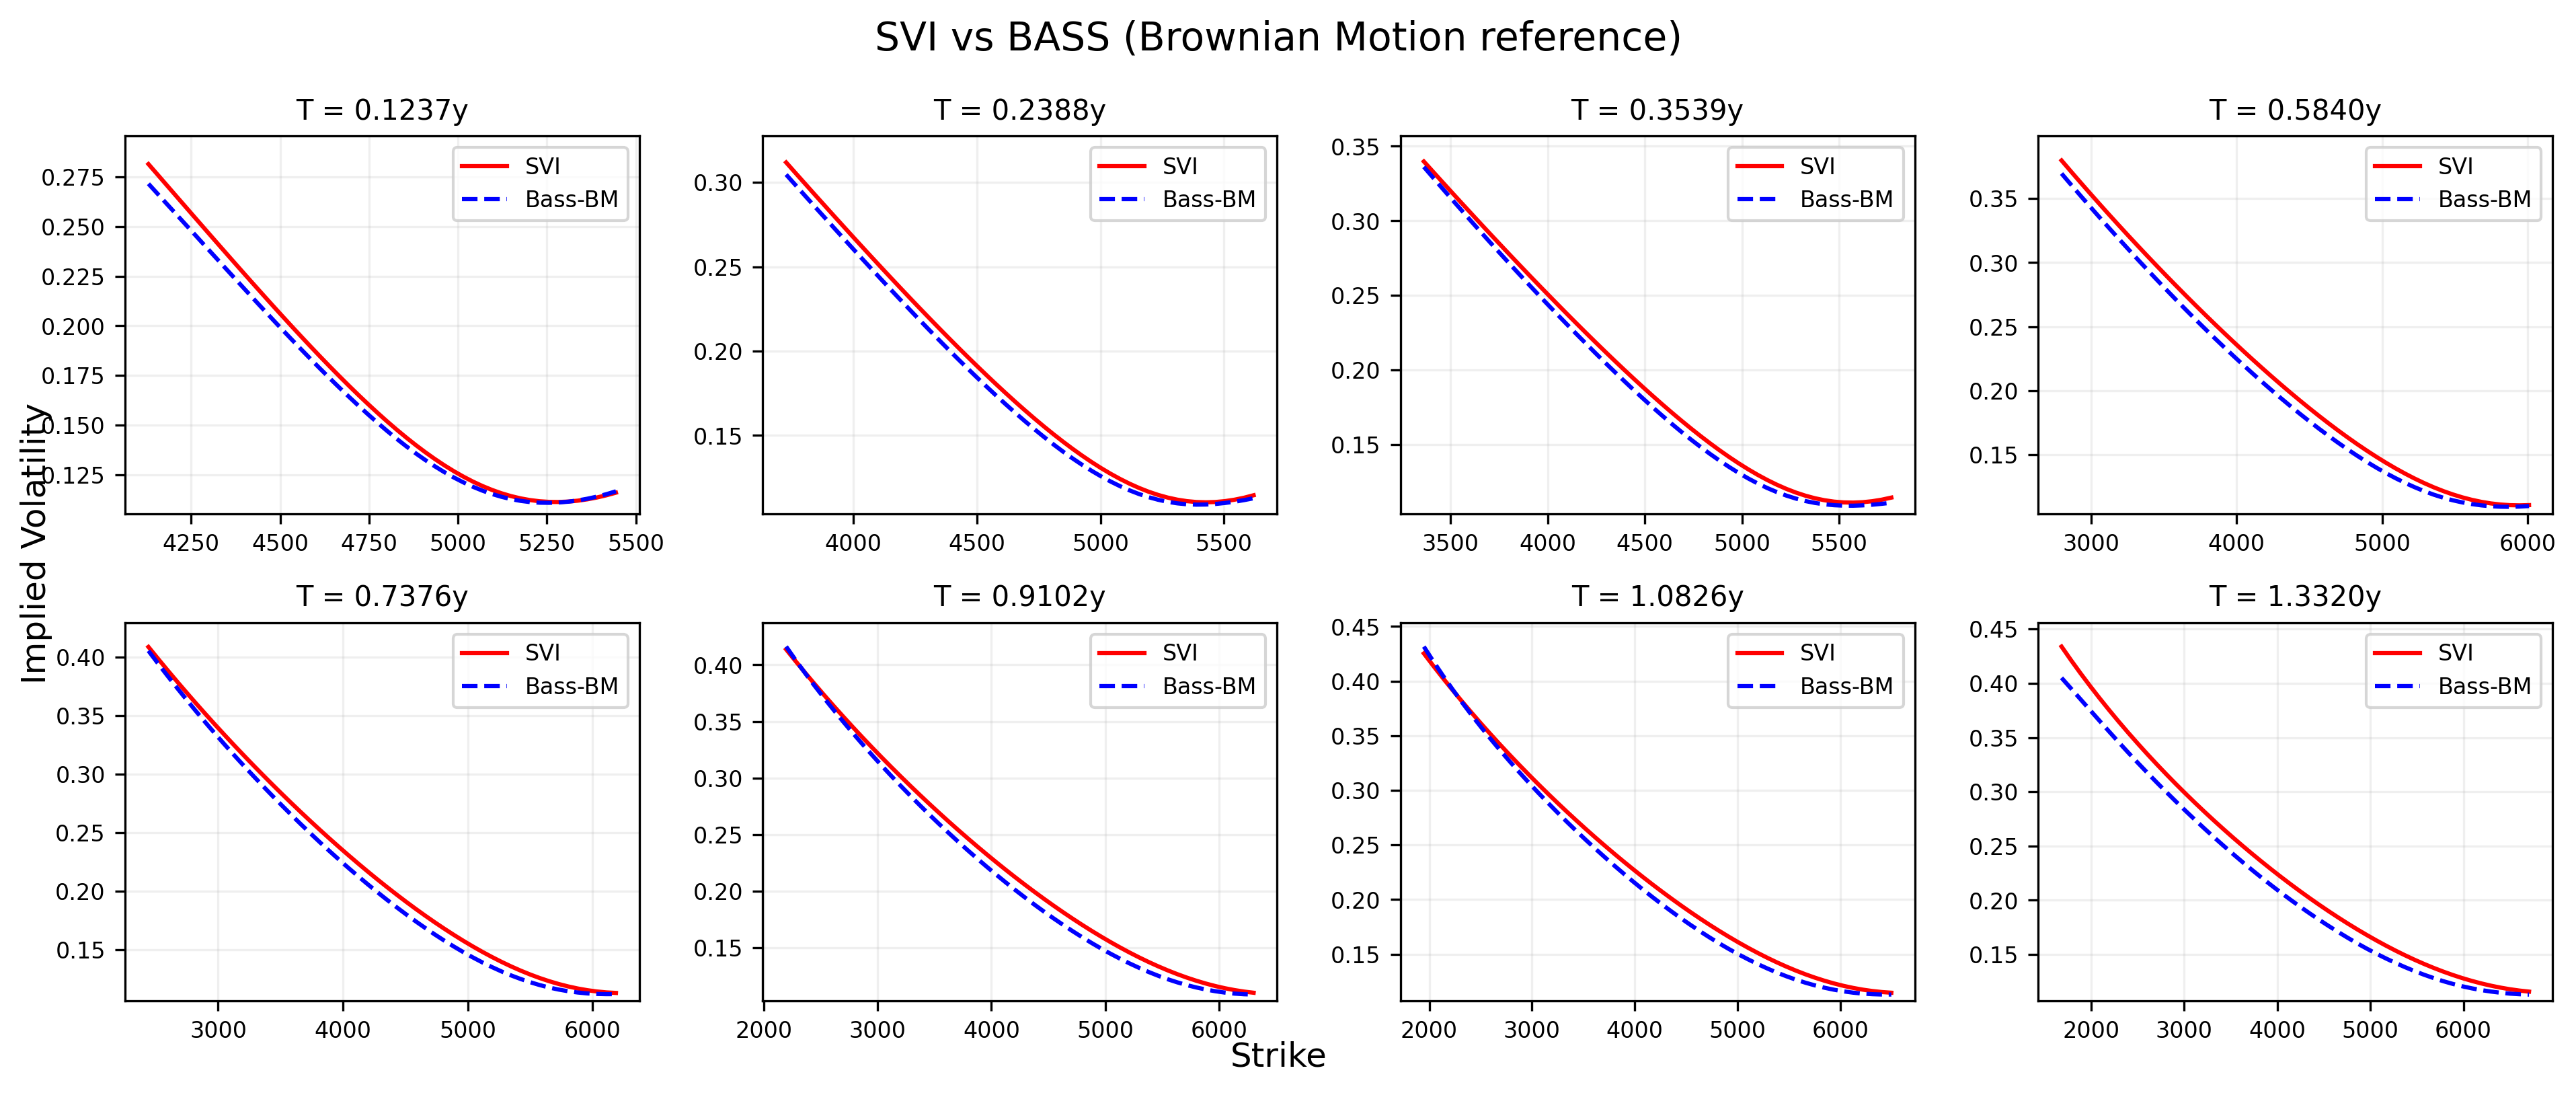

In [14]:
n_paths = 500_000
n_cols  = 4
n_rows  = int(np.ceil(len(all_maturities) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.7 * n_rows), dpi=300)
axes = axes.flatten()

for i, maturity_time in enumerate(all_maturities):
    ax  = axes[i]
    S_t = bass_bm.simulate_smile(i, n_paths, n_steps=300, seed=42 + i)

    strike_min = filtered_marginals[maturity_time].qf(0.01)
    strike_max = filtered_marginals[maturity_time].qf(0.99)
    K_plot     = np.linspace(strike_min, strike_max, 50)

    iv_bass = mc_iv(S0, maturity_time, K_plot, S_t)
    iv_svi  = svi_models[maturity_time].implied_vol(F[i], maturity_time, K_plot)

    ax.plot(K_plot, iv_svi,  color='red',  lw=1.5, label='SVI')
    ax.plot(K_plot, iv_bass, color='blue', lw=1.5, ls='--', label='Bass-BM')

    y_min = min(iv_svi.min(), np.nanmin(iv_bass)) * 0.95
    y_max = max(iv_svi.max(), np.nanmax(iv_bass)) * 1.05
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'T = {maturity_time:.4f}y', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

    clear_output(wait=True)
    display(fig)

for j in range(len(all_maturities), len(axes)):
    axes[j].remove()

fig.text(0.5,  0.02, 'Strike',            ha='center',  fontsize=12)
fig.text(0.02, 0.5,  'Implied Volatility', va='center', rotation='vertical', fontsize=12)
fig.suptitle('SVI vs BASS (Brownian Motion reference)', fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08, left=0.06)
clear_output(wait=True)
display(fig)
plt.savefig('SVI_vs_BASS_BM.pdf', bbox_inches='tight')
plt.show()

### Smile Check — SVI vs Bass SABR

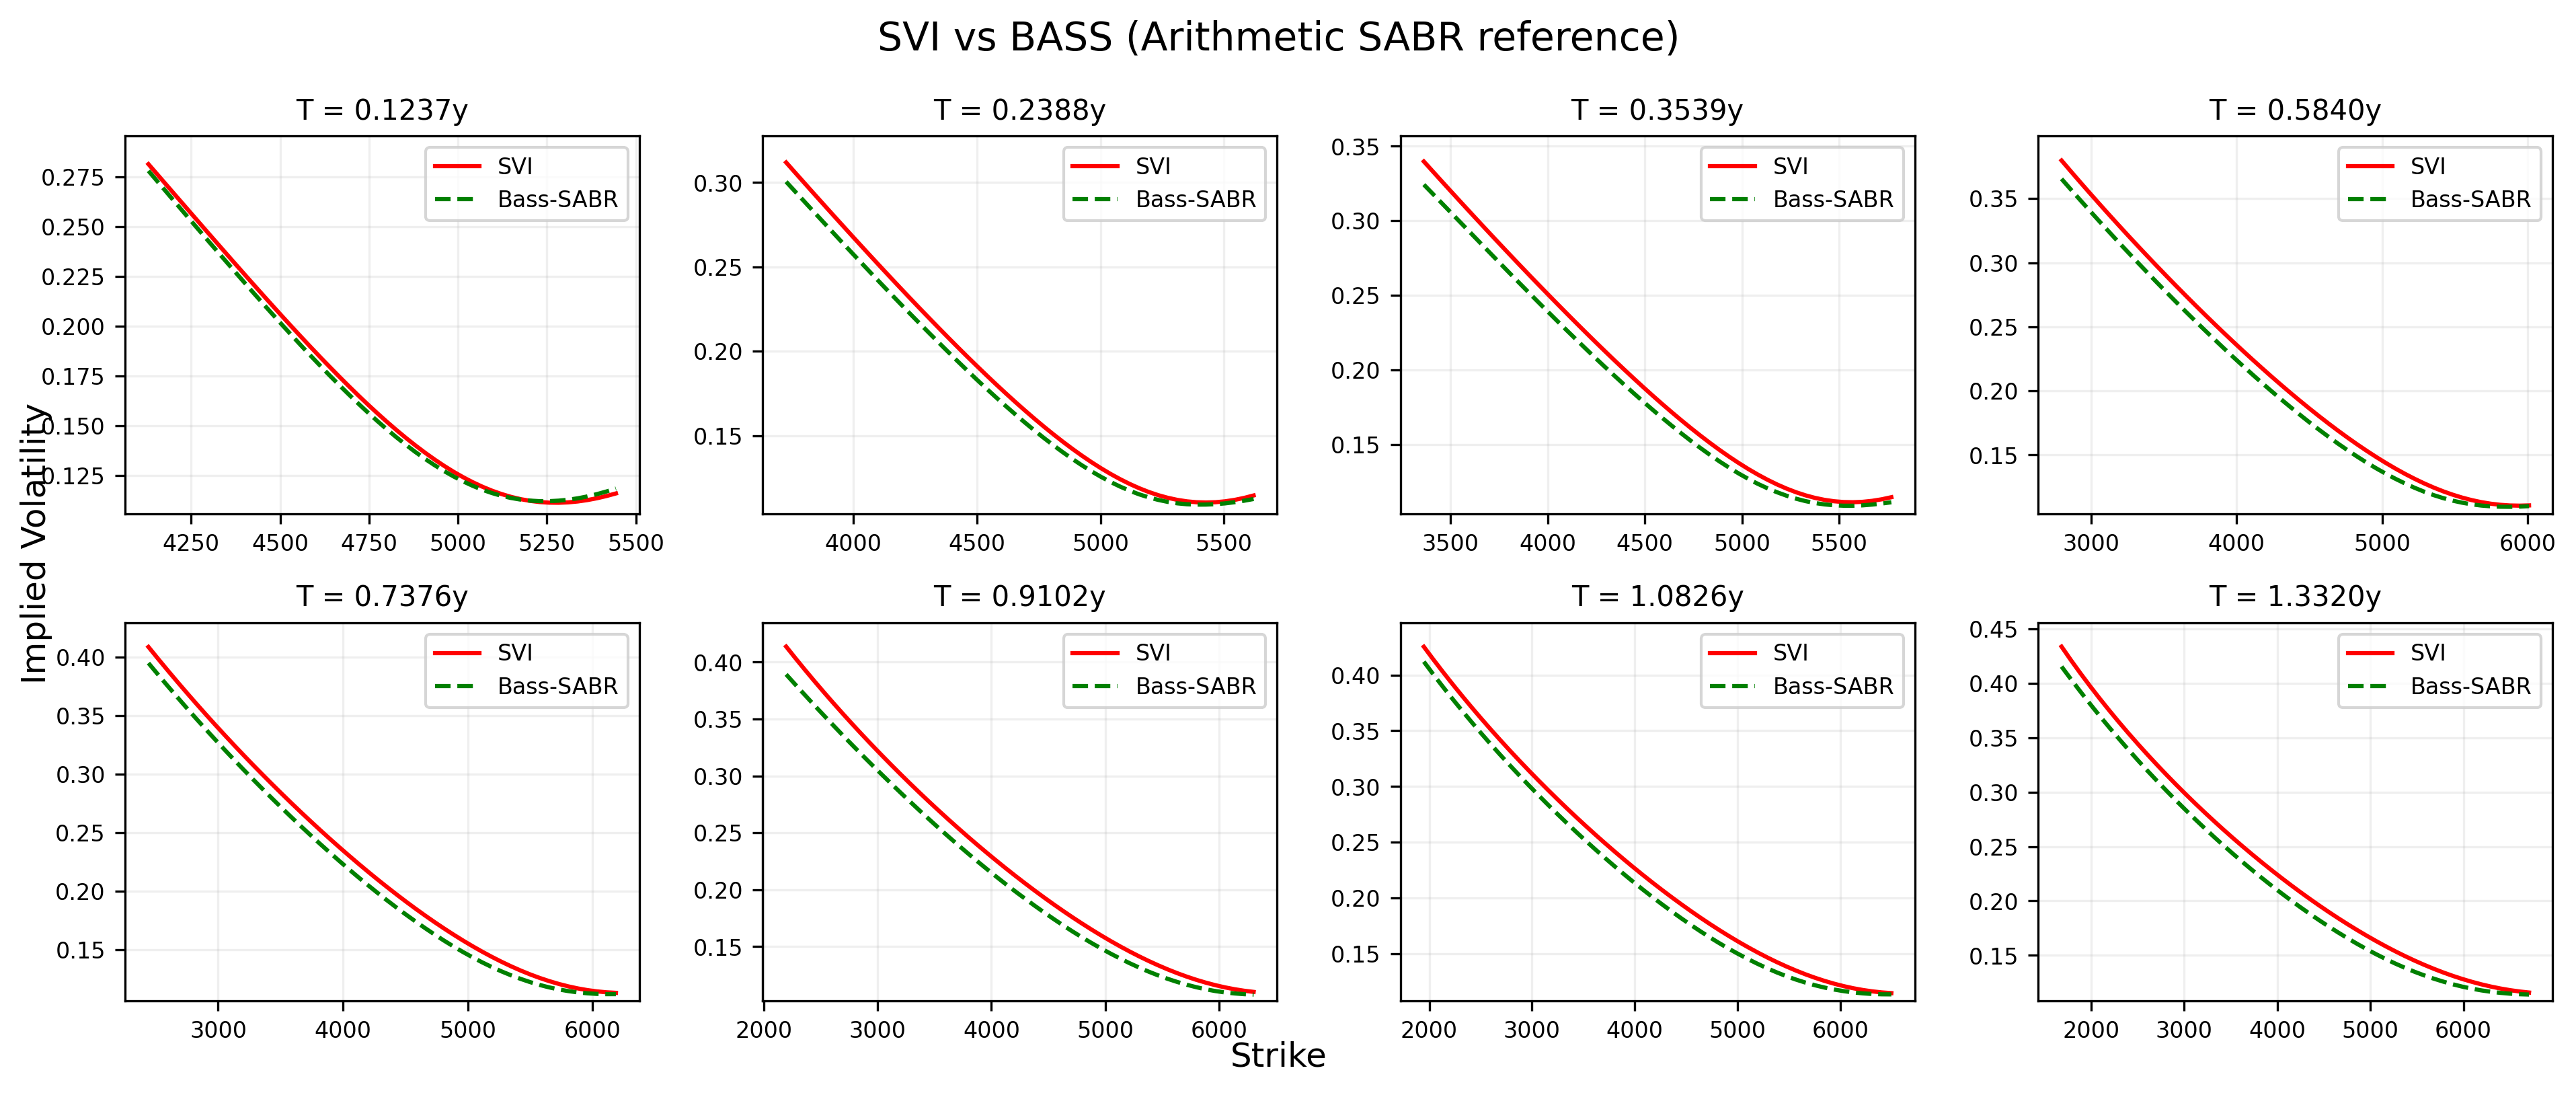

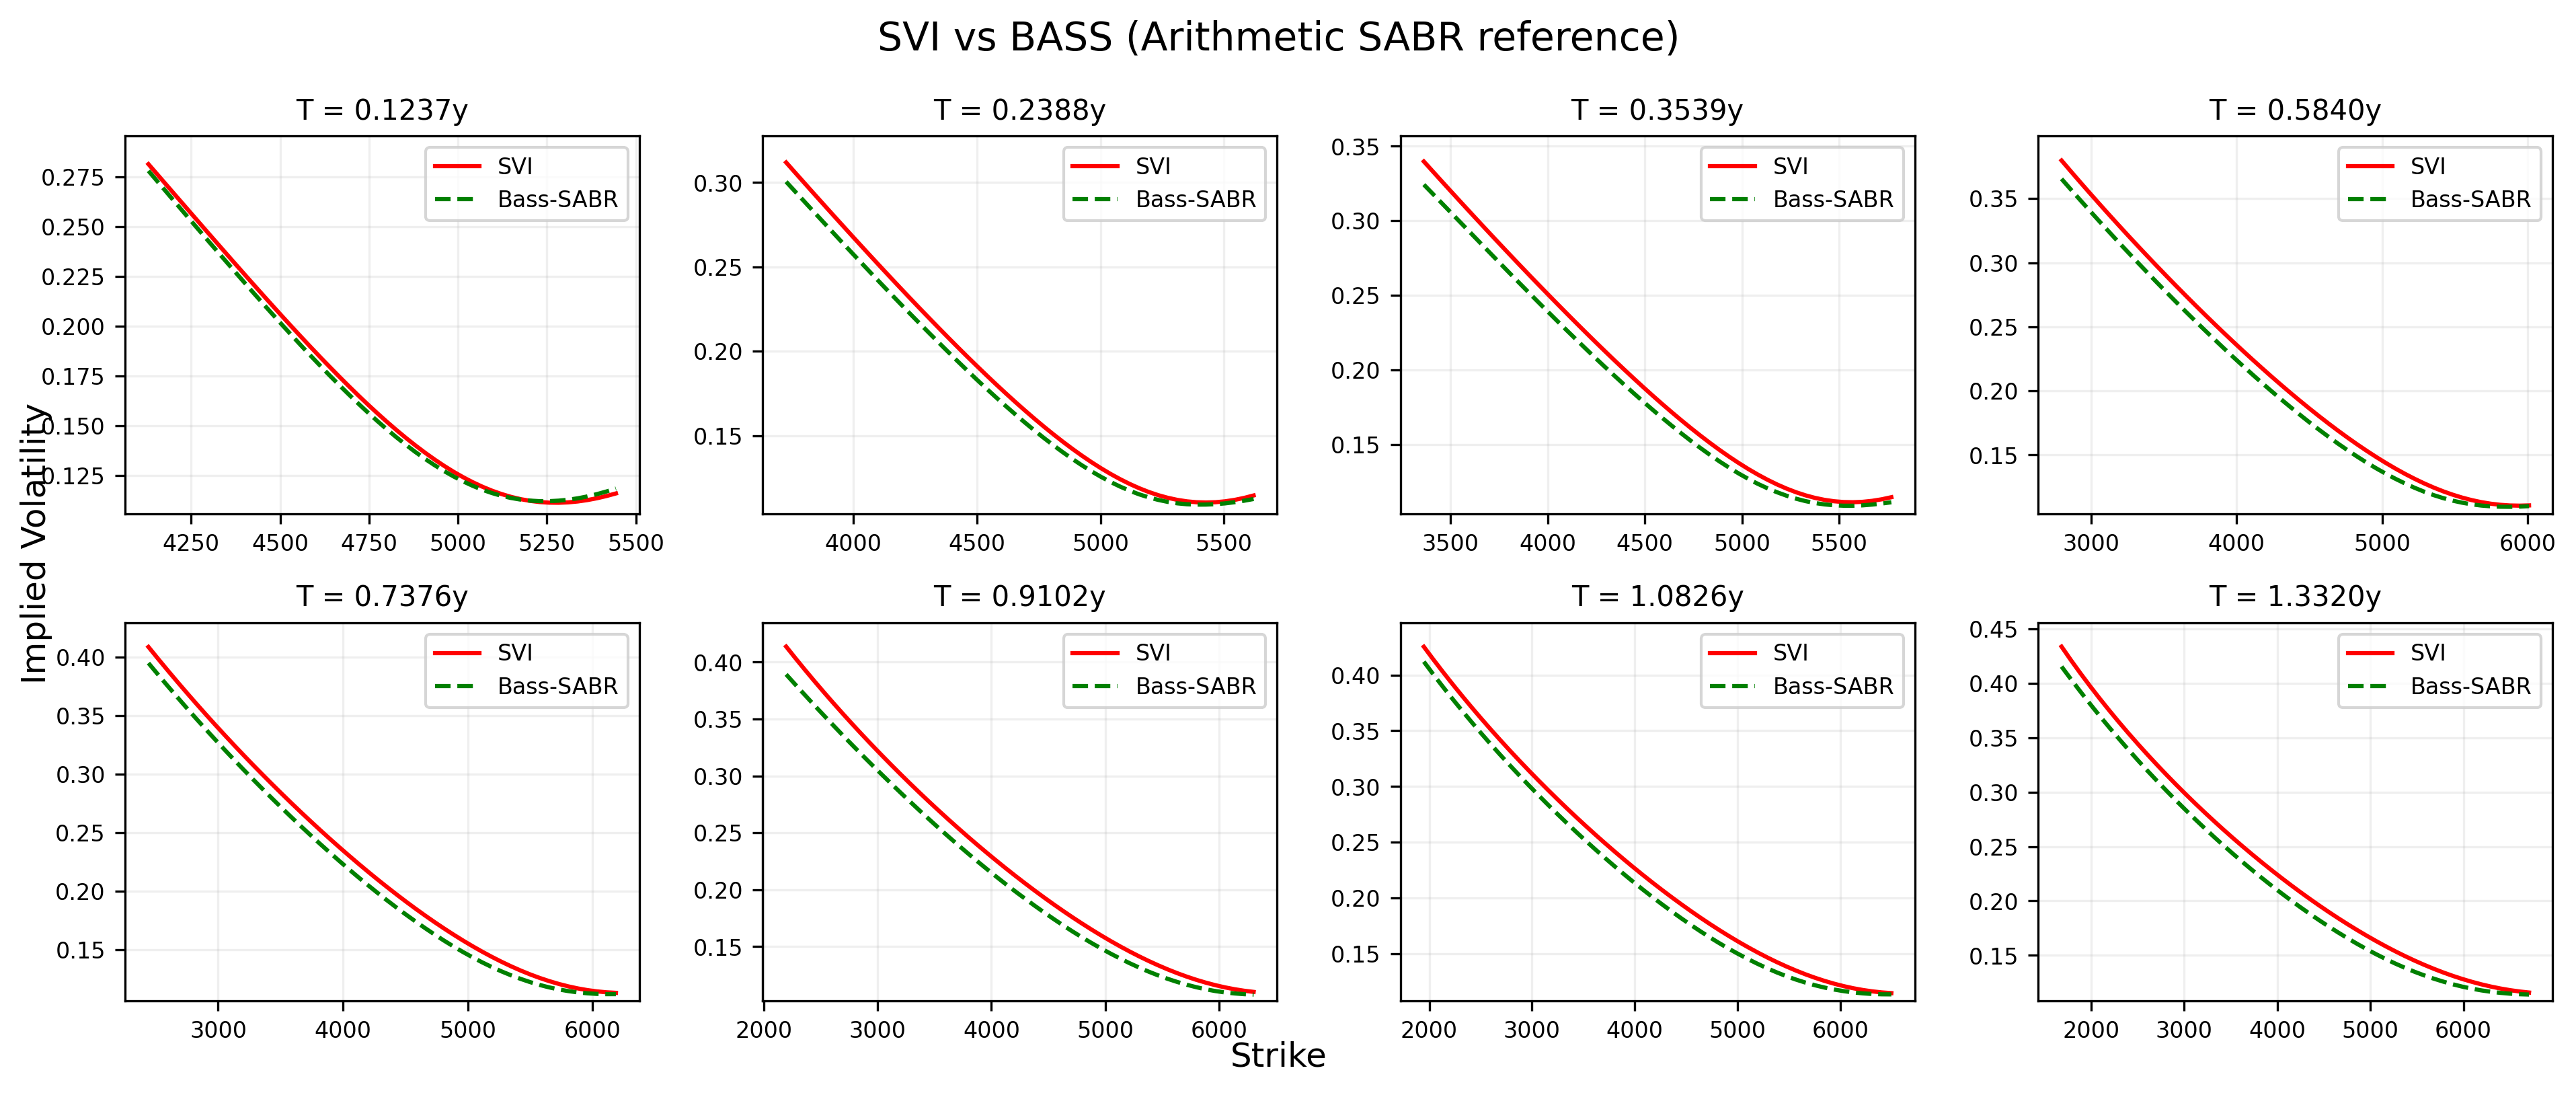

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.7 * n_rows), dpi=300)
axes = axes.flatten()

for i, maturity_time in enumerate(all_maturities):
    ax  = axes[i]
    S_t = bass_sabr.simulate_smile(i, n_paths, n_steps=300, seed=123 + i)

    strike_min = filtered_marginals[maturity_time].qf(0.01)
    strike_max = filtered_marginals[maturity_time].qf(0.99)
    K_plot     = np.linspace(strike_min, strike_max, 50)

    iv_bass = mc_iv(S0, maturity_time, K_plot, S_t)
    iv_svi  = svi_models[maturity_time].implied_vol(F[i], maturity_time, K_plot)

    ax.plot(K_plot, iv_svi,  color='red',   lw=1.5, label='SVI')
    ax.plot(K_plot, iv_bass, color='green', lw=1.5, ls='--', label='Bass-SABR')

    y_min = min(iv_svi.min(), np.nanmin(iv_bass)) * 0.95
    y_max = max(iv_svi.max(), np.nanmax(iv_bass)) * 1.05
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'T = {maturity_time:.4f}y', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

    clear_output(wait=True)
    display(fig)

for j in range(len(all_maturities), len(axes)):
    axes[j].remove()

fig.text(0.5,  0.02, 'Strike',            ha='center',  fontsize=12)
fig.text(0.02, 0.5,  'Implied Volatility', va='center', rotation='vertical', fontsize=12)
fig.suptitle('SVI vs BASS (Arithmetic SABR reference)', fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08, left=0.06)
clear_output(wait=True)
display(fig)
plt.savefig('SVI_vs_BASS_SABR.pdf', bbox_inches='tight')
plt.show()